In [7]:
import sys
from pathlib import Path

import numpy as np
from scipy.interpolate import RegularGridInterpolator

# NumPy 2.x compatibility for older astropy/dsharp_opac code paths
if not hasattr(np, "in1d") and hasattr(np, "isin"):
    np.in1d = np.isin

# Prefer local repository package over a potentially stale site-packages install
cwd = Path.cwd()
if (cwd / "dsharp_opac").exists():
    repo_root = cwd
elif (cwd.parent / "dsharp_opac").exists():
    repo_root = cwd.parent
else:
    repo_root = None

if repo_root is not None and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import dsharp_opac as dop

# Physical constants in cgs
C_LIGHT = 2.99792458e10   # cm/s
H_PLANCK = 6.62607015e-27 # erg*s
K_BOLTZ = 1.380649e-16    # erg/K

def planck_B_nu(nu, T):
    """Planck function B_nu in cgs units (up to common constant factors)."""
    x = np.clip(H_PLANCK * nu / (K_BOLTZ * T), 1e-300, 700.0)
    return 2.0 * H_PLANCK * nu**3 / C_LIGHT**2 / (np.exp(x) - 1.0)

def planck_dBnu_dT(nu, T):
    """Temperature derivative dB_nu/dT in cgs units (numerically stable form)."""
    x = np.clip(H_PLANCK * nu / (K_BOLTZ * T), 1e-8, 700.0)
    ex = np.exp(-x)
    pref = 2.0 * H_PLANCK * nu**3 / C_LIGHT**2
    return pref * (x / T) * ex / (1.0 - ex)**2

# Define parameter grids
T_arr = np.logspace(0, 4, 40)       # 1 - 10000 K
amin_fixed = 1e-5                    # 0.1 um in cm (fixed)
amax_arr = np.logspace(-5, 0, 30)    # 0.1 um - 1 cm (in cm)
slope_arr = np.array([2.5, 3.0, 3.5])  # power-law size distribution slope

# Load precomputed DSHARP opacity table
with np.load(dop.get_datafile('default_opacities_smooth.npz')) as d:
    a = d['a']            # grain-size grid [cm]
    lam = d['lam']        # wavelength grid [cm]
    k_abs = d['k_abs']    # [n_a, n_lam]
    k_sca = d['k_sca']    # [n_a, n_lam]
    g = d['g']            # [n_a, n_lam]

# Extinction used in Rosseland mean
k_ext = k_abs + (1.0 - g) * k_sca
k_ext = np.maximum(k_ext, 1e-60)

nu = C_LIGHT / lam

# Storage: (T, amax, slope)
shape = (len(T_arr), len(amax_arr), len(slope_arr))
kappa_P_table = np.zeros(shape)
kappa_R_table = np.zeros(shape)

for l, amax in enumerate(amax_arr):
    if amax < amin_fixed:
        kappa_P_table[:, l, :] = np.nan
        kappa_R_table[:, l, :] = np.nan
        continue

    for m, slope in enumerate(slope_arr):
        # Power-law mass weighting ~ a^(4-q), truncated to [amin_fixed, amax]
        w = a**(4.0 - slope)
        w[(a < amin_fixed) | (a > amax)] = 0.0
        wsum = w.sum()

        if wsum <= 0.0:
            kappa_P_table[:, l, m] = np.nan
            kappa_R_table[:, l, m] = np.nan
            continue

        w /= wsum
        k_abs_mix = (k_abs.T * w[None, :]).sum(axis=1)
        k_ext_mix = (k_ext.T * w[None, :]).sum(axis=1)
        k_ext_mix = np.maximum(k_ext_mix, 1e-60)

        # Planck & Rosseland means at each temperature
        for i, T in enumerate(T_arr):
            Bnu = planck_B_nu(nu, T)
            dB = planck_dBnu_dT(nu, T)

            B_int = np.trapezoid(Bnu, x=nu)
            dB_int = np.trapezoid(dB, x=nu)

            kP = np.trapezoid(Bnu * k_abs_mix, x=nu) / B_int
            kR = dB_int / np.trapezoid(dB / k_ext_mix, x=nu)

            kappa_P_table[i, l, m] = kP
            kappa_R_table[i, l, m] = kR

# Replace NaNs / zeros with tiny number to avoid log issues
eps = 1e-40
kappa_P_table = np.where(np.isfinite(kappa_P_table) & (kappa_P_table > 0),
                         kappa_P_table, eps)
kappa_R_table = np.where(np.isfinite(kappa_R_table) & (kappa_R_table > 0),
                         kappa_R_table, eps)

# Build interpolators in log-log space: axes are (T, amax, slope)
log_axes = (np.log10(T_arr), np.log10(amax_arr), slope_arr)

_interp_P = RegularGridInterpolator(
    log_axes, np.log10(kappa_P_table),
    method='linear', bounds_error=False, fill_value=None
)
_interp_R = RegularGridInterpolator(
    log_axes, np.log10(kappa_R_table),
    method='linear', bounds_error=False, fill_value=None
)

def kappa_P(T, amax, slope):
    """
    Planck mean opacity [cm^2/g] for fixed amin = 0.1 um.
    T, amax, slope can be scalars or arrays (broadcast-compatible).
    """
    T, amax, slope = np.broadcast_arrays(T, amax, slope)
    pts = np.column_stack([
        np.log10(T.ravel()),
        np.log10(amax.ravel()),
        slope.ravel()
    ])
    return 10 ** _interp_P(pts).reshape(T.shape)

def kappa_R(T, amax, slope):
    """
    Rosseland mean opacity [cm^2/g] for fixed amin = 0.1 um.
    T, amax, slope can be scalars or arrays (broadcast-compatible).
    """
    T, amax, slope = np.broadcast_arrays(T, amax, slope)
    pts = np.column_stack([
        np.log10(T.ravel()),
        np.log10(amax.ravel()),
        slope.ravel()
    ])
    return 10 ** _interp_R(pts).reshape(T.shape)

# Quick sanity check
print("Fixed amin =", amin_fixed, "cm (0.1 um)")
print("kappa_P(100 K, amax=1 cm, q=3.5) =", kappa_P(100, 1.0, 3.5), "cm^2/g")
print("kappa_R(100 K, amax=1 cm, q=3.5) =", kappa_R(100, 1.0, 3.5), "cm^2/g")

Fixed amin = 1e-05 cm (0.1 um)
kappa_P(100 K, amax=1 cm, q=3.5) = 30.34881261121207 cm^2/g
kappa_R(100 K, amax=1 cm, q=3.5) = 39.883378836047775 cm^2/g


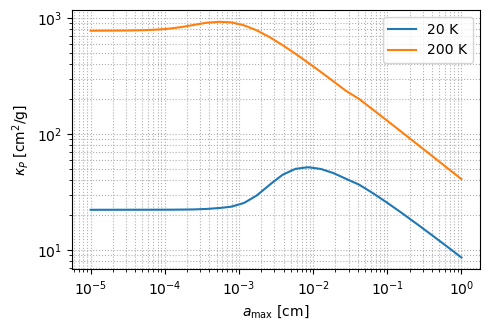

In [12]:
import matplotlib.pyplot as plt

# IMPORTANT: kappa_P(T, amax, slope) in Cell 1 is calibrated for amax in [1e-5, 1] cm
amax_plot = np.logspace(-5, 0, 200)  # 0.1 um to 1 cm

plt.figure(figsize=(5.0, 3.4))
plt.loglog(amax_plot, kappa_P(20.0, amax_plot, 3.5), label='20 K')
plt.loglog(amax_plot, kappa_P(200.0, amax_plot, 3.5), label='200 K')
plt.xlabel(r'$a_{\max}$ [cm]')
plt.ylabel(r'$\kappa_P$ [cm$^2$/g]')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

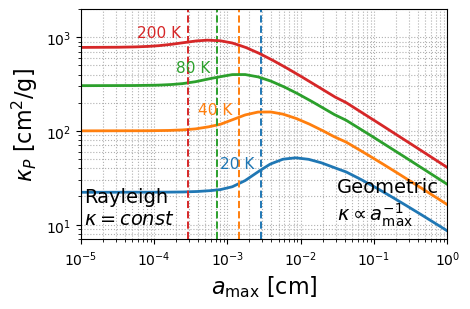

In [16]:
import matplotlib.pyplot as plt

# Styled version of the Cell-2 plot, using exactly the same function from Cell 1
T_list = [20.0, 40, 80, 200.0]
slope_use = 3.5
amax_plot = np.logspace(-5, 0, 400)  # 0.1 um to 1 cm

# Characteristic wavelength marker: a_transition = lambda_char / (2*pi)
x_peak = 3.9206903949  # peak of nu*B_nu
hc_over_k = H_PLANCK * C_LIGHT / K_BOLTZ

fig, ax = plt.subplots(figsize=(4.8, 3.2))

for i, T in enumerate(T_list):
    color = f'C{i}'
    y = kappa_P(T, amax_plot, slope_use)
    ax.loglog(amax_plot, y, lw=2, color=color)

    # Transition guide line (same definition as in planck_opacity_vs_a notebook)
    lambda_char = (hc_over_k / T) / x_peak
    a_transition = lambda_char / (2.0 * np.pi)
    ax.axvline(a_transition, color=color, ls='--', lw=1.4)

    # Place temperature label just left of transition line
    x_label = np.clip(a_transition / 1.25, amax_plot[0] * 1.1, amax_plot[-1] / 1.1)
    y_label = 10 ** np.interp(np.log10(x_label), np.log10(amax_plot), np.log10(y))
    ax.text(x_label, y_label * 1.08, f"{T:.0f} K", color=color, fontsize=11, ha='right', va='bottom')

ax.set_xlabel(r'$a_{\max}$ [cm]', fontsize=16)
ax.set_ylabel(r'$\kappa_P$ [cm$^2$/g]', fontsize=16)
ax.text(0.01, 0.05, 'Rayleigh\n$\\kappa=const$', transform=ax.transAxes, fontsize=14, ha='left', va='bottom')
ax.text(0.70, 0.05, 'Geometric\n$\\kappa\\propto a_{\\max}^{-1}$', transform=ax.transAxes, fontsize=14, ha='left', va='bottom')
ax.grid(True, which='both', ls=':')
ax.set_xlim(1e-5, 1e0)
ax.set_ylim(7e0, 2e3)
plt.tight_layout()
plt.show()

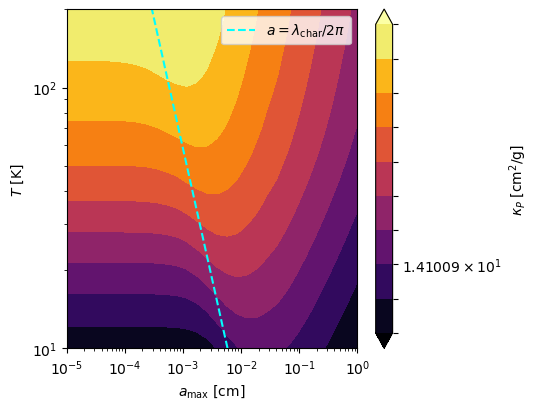

In [17]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 2D contour map of the same Planck-mean opacity surface used above
# Fixed parameters: amin = 0.1 um, slope = 3.5
T_map = np.logspace(np.log10(10.0), np.log10(200.0), 120)
amax_map = np.logspace(-5, 0, 140)  # 0.1 um to 1 cm
slope_map = 3.5

TT, AA = np.meshgrid(T_map, amax_map, indexing='ij')
kappa_map = kappa_P(TT, AA, slope_map)

kmin = np.nanmin(kappa_map)
kmax = np.nanmax(kappa_map)
levels = np.logspace(np.log10(kmin), np.log10(kmax), 10)  # 10 contour levels

fig, ax = plt.subplots(figsize=(5.4, 4.2))
cs = ax.contourf(
    amax_map,
    T_map,
    kappa_map,
    levels=levels,
    norm=LogNorm(vmin=kmin, vmax=kmax),
    cmap='inferno',
    extend='both',
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a_{\max}$ [cm]')
ax.set_ylabel(r'$T$ [K]')
cbar = fig.colorbar(cs, ax=ax)
cbar.set_label(r'$\kappa_P$ [cm$^2$/g]')

# Optional reference line: geometric transition a = lambda_char / (2 pi)
x_peak = 3.9206903949
hc_over_k = H_PLANCK * C_LIGHT / K_BOLTZ
T_line = np.array([10.0, 200.0])
lambda_char_line = (hc_over_k / T_line) / x_peak
a_transition_line = lambda_char_line / (2.0 * np.pi)
ax.plot(a_transition_line, T_line, '--', color='cyan', lw=1.5, label=r'$a=\lambda_{\rm char}/2\pi$')

ax.set_xlim(1e-5, 1e0)
ax.set_ylim(10.0, 200.0)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()